# 2. Choose a backend

Both backends predict Jeans velocity moments from a tracer, halo and
anisotropy. Their parameter interfaces and numerical implementations differ.
The Quickstart uses **JAX/NumPyro** so the likelihood can supply gradients to
NUTS. Choose NumPy/SciPy when you need its profile implementations or a
stateful interface.


This notebook is self-contained. Install JeansPy with the `numpyro_cpu` and
`plotting` extras as described in the installation guide, then select that
environment as your Jupyter kernel and run cells from top to bottom.
Saved outputs are an example run; timings and short-chain results can vary.

## Decide which interface you need

| Choice | NumPy/SciPy | JAX |
| --- | --- | --- |
| Spherical import | `jeanspy.model` | `jeanspy.model_jax` |
| Physical parameters | Stored in components; change with `update(...)` | Passed explicitly in `params` or named method arguments |
| Computation | CPU NumPy/SciPy | JAX device arrays, optional JIT compilation |
| Physical-parameter gradients | No JAX automatic differentiation | Available on supported differentiable paths |
| Sampling used here | emcee ensemble sampler | NumPyro NUTS |
| Repeated calls | No JIT compilation cost | Can reuse compiled calculations with compatible shapes and static options |

Backend choice does not change the intended physical units. It does change
available models, argument names, returned shapes and numerical defaults.
For example, the NumPy/SciPy spherical solver has `sigmalos` and `sigmalos2`;
the JAX model exposes `sigmalos2`, whose square root gives the dispersion.
The profile catalogues are not identical. See the two sections of the
[spherical API](../api/spherical.rst) before switching a component.

## Build the same model twice

This executable example uses the same physical values and radius grid for
both backends. The NumPy/SciPy components receive constructor parameters;
the JAX components receive a dictionary at evaluation time.

In [1]:
import os
os.environ.setdefault("JEANSPY_JAX_PLATFORM", "cpu")
os.environ.setdefault("JEANSPY_JAX_ENABLE_X64", "true")

from jeanspy import model as numpy_backend
from jeanspy import model_jax as jax_backend
import jax
import jax.numpy as jnp
import numpy as np
from time import perf_counter

params = dict(re_pc=200., rs_pc=500., rhos_Msunpc3=.1,
              r_t_pc=5000., beta_ani=0.)
R_pc = np.geomspace(20., 1000., 32)
numpy_model = numpy_backend.DSphModel(vmem_kms=0., submodels={
    "StellarModel": numpy_backend.PlummerModel(re_pc=params["re_pc"]),
    "DMModel": numpy_backend.NFWModel(**{k: params[k] for k in
                                    ("rs_pc", "rhos_Msunpc3", "r_t_pc")}),
    "AnisotropyModel": numpy_backend.ConstantAnisotropyModel(beta_ani=0.),
})
jax_model = jax_backend.DSphModel(submodels={
    "StellarModel": jax_backend.PlummerModel(),
    "DMModel": jax_backend.NFWModel(),
    "AnisotropyModel": jax_backend.ConstantAnisotropyModel(),
})
print(jax_backend.get_runtime_config())
print(jax.devices())
#

{'jax_platform_requested': 'cpu', 'jax_platform_effective_env': 'cpu', 'jax_backend_active': 'cpu', 'jax_enable_x64': True, 'kernel_backend_default': 'jax', 'constant_kernel_n_quad_default': 32, 'sigmalos2_solver_default': 'auto', 'sigmalos2_jit_default': True, 'sigmalos2_kernel_outer_transform_default': 'sqrtlog', 'baes_kernel_n_quad_default': 32, 'baes_eta_recommended_max': 10.0, 'sigmalos2_n_u_default': 128, 'sigmalos2_n_r_default': 768, 'sigmalos2_u_max_default': 10000.0}
[CpuDevice(id=0)]


Set the platform and precision before importing JAX, including in notebooks.
If JAX is already initialized, restart the kernel before applying the setup.
`get_runtime_config()` and `jax.devices()` report the effective settings;
installing GPU dependencies alone does not establish which device is active.

## Measure first-call and repeated-call time separately

In [2]:
start = perf_counter()
numpy_variance = numpy_model.sigmalos2(R_pc, n=512, n_kernel=128)
numpy_seconds = perf_counter() - start
R_jax = jnp.asarray(R_pc)
jax_params = {name: jnp.asarray(value) for name, value in params.items()}
jax.block_until_ready((R_jax, jax_params))  # Complete transfers before timing.

def predict(p):
    return jax_model.sigmalos2(R_jax, params=p, solver="kernel",
                               kernel_backend="jax", n_u=512, n_kernel=128)

start = perf_counter()
jax_variance = jax.block_until_ready(predict(jax_params))
first_seconds = perf_counter() - start
times = []
for _ in range(5):
    start = perf_counter()
    jax.block_until_ready(predict(jax_params))
    times.append(perf_counter() - start)
relative_difference = np.max(np.abs(np.asarray(jax_variance) / numpy_variance - 1.))
print({"numpy_call_s": numpy_seconds, "jax_first_call_s": first_seconds,
       "jax_repeated_median_s": float(np.median(times)),
       "max_relative_variance_difference": float(relative_difference)})
#

{'numpy_call_s': 0.002242557005956769, 'jax_first_call_s': 0.4148756011854857, 'jax_repeated_median_s': 0.0014606988988816738, 'max_relative_variance_difference': 3.200623051036189e-07}


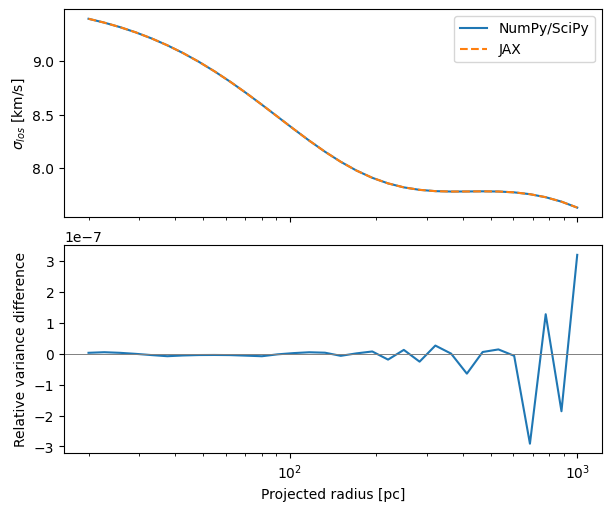

In [3]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 1, figsize=(6, 5), sharex=True, layout="constrained")
axes[0].semilogx(R_pc, np.sqrt(numpy_variance), label="NumPy/SciPy")
axes[0].semilogx(R_pc, np.sqrt(np.asarray(jax_variance)), ls="--", label="JAX")
axes[0].set_ylabel(r"$\sigma_{los}$ [km/s]")
axes[0].legend()
axes[1].semilogx(R_pc, np.asarray(jax_variance)/numpy_variance - 1.)
axes[1].axhline(0., color="gray", lw=.7)
axes[1].set(xlabel="Projected radius [pc]", ylabel="Relative variance difference")
plt.show()

JAX dispatch is asynchronous, so wait for completion with
`jax.block_until_ready`. The first call includes tracing, compilation and
execution; the median of later calls measures reuse of that compiled shape.
The code completes input transfers before either JAX timing. New array
shapes, node counts or static backend choices can require another compilation.

The printed difference compares the two **variances**, not their square roots.
Equal node counts do not imply equal quadrature rules or accuracy. Refine
each solver and compare predictions at an accuracy appropriate to the analysis
before comparing speed. A small one-off calculation can favor NumPy; repeated
large calculations may benefit from JIT or a GPU. There is no universal speed
ordering, and this example supplies no frozen performance claim. Include
likelihood, gradient, transfer and compilation costs for the workload you
actually intend to run.

## Differentiate a physical parameter

In [4]:
def summed_variance(log_density):
    return jnp.sum(predict({**jax_params, "rhos_Msunpc3": jnp.exp(log_density)}))

log_density = jnp.log(jax_params["rhos_Msunpc3"])
derivative = jax.block_until_ready(jax.grad(summed_variance)(log_density))
# With a massless tracer and fixed shape, sigma^2 scales linearly with rho_s.
np.testing.assert_allclose(derivative, jnp.sum(jax_variance), rtol=1e-8)
assert np.all(np.isfinite(numpy_variance)) and np.all(np.asarray(jax_variance) > 0)
print("d(sum sigma_los^2) / d(ln rho_s):", float(derivative))
#

d(sum sigma_los^2) / d(ln rho_s): 2239.4195206705785


This checks a derivative with a known scaling: at fixed halo shape and
massless tracer, $\sigma_{los}^2$ is proportional to the halo density scale.
For other parameters, check gradients against finite differences and refined
quadrature on the intended domain. Use JAX operations in transforms and
custom components; converting a traced value with `float` or `np.asarray`
breaks that calculation.

The `solver="kernel"` option above selects a numerical route **within JAX**;
it is separate from selecting NumPy versus JAX by import. For the constant
anisotropy kernel, `kernel_backend="jax"` keeps the path in JAX.
The SciPy callback alternative is not an all-JAX differentiable kernel.
Cutoffs, validity masks and discrete choices also need care at boundaries.
Current J/D-factor postprocessing uses NumPy and is not a differentiable
continuation of NUTS.

Rerun this notebook to inspect timings on your machine. The displayed timings
are a single illustrative run, not a portable performance benchmark.
Next: [define and extend models](models.ipynb).